The idea behind this notebook was to run a variety of EI on the data that we got from er total run. In particular, we are going to be making the following tables:
1. $2\times 2$ ER and EI -- (H,$SOR_O$)
2. $2\times 2$ ER and EI -- (Brazilian, $SOR_O$)
3. $2\times 2$ ER and EI -- (Guyanese, $SOR_O$)
4. $2\times 2$ ER and EI -- (Cabo Verdean, $SOR_O$)
5. $2\times 2$ ER and EI -- (Belizean, $SOR_O$)
6. $2 \times 4$ ER and EI -- (Brazilian, $SOR_O$, $W_0$, $B_0$)
7. $2\times 2$ ER and EI -- (Guyanese, H)
8. $2\times 2$ ER and EI -- (Cabo Verdean, $B_0$)
9. $2\times 2$ ER and EI -- (Belizean, H)
10. $2\times 2$ ER and EI -- (MENAW, $SOR_O$)
11. $2\times 2$ ER and EI -- (MENAH, $SOR_O$)
12. $2\times 2$ ER and EI -- (MENAS, $SOR_O$)
13. $2\times 2$ ER and EI -- (MENAW, $W_0$)
14. $2\times 2$ ER and EI -- (MENAH, $W_0$)
15. $2\times 2$ ER and EI -- (MENAS, $W_0$)

In [1]:
import json

import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests
import us

from census import Census
from shapely.geometry import Point
import numpy as np
import pandas as pd

from pyei.two_by_two import TwoByTwoEI
from pyei.goodmans_er import GoodmansER
from pyei.goodmans_er import GoodmansERBayes
from pyei.r_by_c import RowByColumnEI


/mnt/efs/h/Dropbox/MADLAB/Student_projects/sum25_pyei/.venv/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Read in the dataframes

In [2]:

states_fips = [
    "06", # California
    "25", # Massachusetts
    "26", # Michigan
    "36", # New York
    # "48" # Texas
] #these are the states whose files we got in ertotalrun.ipynb

state_dfs = ['0']*len(states_fips)

for i, state in enumerate(states_fips):
    df = pd.read_csv('csv_files/' + state + 'ecological_acs_pl.csv')
    state_dfs[i] = df

for i in range(len(state_dfs)):
    state_dfs[i].fillna(0, inplace = True) #the EI won't run otherwise


In [3]:
print(state_dfs)

[      Unnamed: 0  totpop_PL  hispanic_PL  white_PL  black_PL  sor_PL  state  \
0              0       3038          205      2645       144      80      6   
1              1       2001          207      1716        40      41      6   
2              2       5504          547      4772       561     191      6   
3              3       4112          374      3595       289     122      6   
4              4       3644          437      3086       625     168      6   
...          ...        ...          ...       ...       ...     ...    ...   
9124        9124       2412          430      2003       214      72      6   
9125        9125       3594          626      3205        26     358      6   
9126        9126       3935          387      3562        22     147      6   
9127        9127       3187          254      2817        33      86      6   
9128        9128       1506          150      1311         6      12      6   

      county   tract       GEOID  ...  sudanese_AC

In [ ]:
def two_by_two(df, race, ancestry_or_ethnicity, total_col):
    candidate_name_2by2 = race
    demographic_group_name_2by2 = ancestry_or_ethnicity
    precinct_names = df['tract'].astype(str)
    group_fraction_2by2 = np.array(df[ancestry_or_ethnicity]) # Change this AND candidate name below
    votes_fraction_2by2 = np.array(df[race]) #Change this AND group name below
    precinct_pops = np.array(df[total_col]).astype(int)
    ei_2by2 = TwoByTwoEI(model_name="king99_pareto_modification", pareto_scale=15, pareto_shape=2)
    ei_2by2.fit(
          group_fraction_2by2,
          votes_fraction_2by2,
          precinct_pops,
          demographic_group_name=demographic_group_name_2by2,
          candidate_name=candidate_name_2by2,
          precinct_names=precinct_names, # omit this line if you don't have or don't want to use precinct names
          chains=4
    )
    # Generate a simple report to summarize the results
    print(ei_2by2.summary())
    return ei_2by2

In [5]:
def plot_ei(ei_2by2):

    fig, ax = plt.subplots(2)

    ei_2by2.plot(axes=ax)

    ax[0].set_xlim(-0.1,1.01)
    ax[1].set_xlim(-0.1, 1.01)

In [6]:
def er(group_fraction_2by2, demographic_group_name_2by2, votes_fraction_2by2, precinct_pops, candidate_name_2by2):
    goodmans_er = GoodmansER(is_weighted_regression="True")

    goodmans_er.fit(
        group_fraction_2by2,
        votes_fraction_2by2,
        precinct_pops, # Must include populations if weighting by population
        demographic_group_name=demographic_group_name_2by2,
        candidate_name=candidate_name_2by2
    )
    print(goodmans_er.summary())
    goodmans_er.plot()

# 2x2

## Tracts, California

In [7]:


# # (H, SOR_0)
# ca_sor_hispanic = two_by_two(state_dfs[0], 'sor_PL_pct', 'hispanic_PL_pct', 'totpop_PL')
# plot(ca_sor_hispanic)
# er(np.array(state_dfs[0]['hispanic_PL_pct']), np.array(state_dfs[0]['sor_PL_pct']), np.array(state_dfs[0]['totpop_PL']).astype(int))

# # (Brazilian, SOR_0)
# ca_sor_brazil = two_by_two(state_dfs[0], 'sor_ACS_pct', 'brazilian_ACS_pct', 'totpop_ACS')
# plot(ca_sor_brazil)
# er(np.array(state_dfs[0]['brazilian_ACS_pct']), np.array(state_dfs[0]['sor_ACS_pct']), np.array(state_dfs[0]['totpop_ACS']).astype(int))

# # (Guyanese, SOR_0)
# pop = 'guyanese_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ca_sor_guy = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_sor_guy)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Cabo Verdean, SOR_0)
# pop = 'cabo_verdean_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ca_sor_cabo = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_sor_cabo)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Belizean, SOR_0)
# pop = 'belizean_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ca_sor_bel = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_sor_bel)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Brazilian, H)
# pop = 'brazilian_ACS_pct'
# race = 'hispanic_PL_pct'
# total_pop = 'totpop_PL'
# ca_hispanic_brazil = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_hispanic_brazil)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Guyanese, H)
# pop = 'guyanese_ACS_pct'
# race = 'hispanic_PL_pct'
# total_pop = 'totpop_PL'
# ca_hispanic_guy = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_hispanic_guy)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Cabo Verde, B_0)
# pop = 'cabo_verdean_ACS_pct'
# race = 'black_PL_pct'
# total_pop = 'totpop_PL'
# ca_black_cabo = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_black_cabo)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Belizean, H)
# pop = 'belizean_ACS_pct'
# race = 'hispanic_PL_pct'
# total_pop = 'totpop_PL'
# ca_hispanic_belize = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_hispanic_belize)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Mena_WB, SOR_0)
# pop = 'mena_world_bank_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ca_sor_world_bank = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_sor_world_bank)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Mena_UNHC, SOR_0)
# pop = 'mena_unhcr_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ca_sor_unhcr = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_sor_unhcr)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Mena_UNSC, SOR_0)
# pop = 'mena_unsd_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ca_sor_unsd = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_sor_unsd)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Mena_WB, W_0)
# pop = 'mena_world_bank_ACS_pct'
# race = 'white_PL_pct'
# total_pop = 'totpop_PL'
# ca_w_world_bank = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_w_world_bank)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Mena_UNHC, W_0)
# pop = 'mena_unhcr_ACS_pct'
# race = 'white_PL_pct'
# total_pop = 'totpop_PL'
# ca_w_unhcr = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_w_unhcr)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

# # (Mena_UNSC, SOR_0)
# pop = 'mena_unsd_ACS_pct'
# race = 'white_PL_pct'
# total_pop = 'totpop_PL'
# ca_w_unsd = two_by_two(state_dfs[0], race, pop, total_pop)
# plot(ca_w_unsd)
# er(np.array(state_dfs[0][pop]), np.array(state_dfs[0][race]), np.array(state_dfs[0][total_pop]).astype(int))

## Tracts, Mass

/mnt/efs/h/Dropbox/MADLAB/Student_projects/sum25_pyei/.venv/lib/python3.10/site-packages/pyei/two_by_two.py:812: UserWarning: Precinct names are not unique. This may interfere with passing precinct names to precinct_level_plot().
  warnings.warn(


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        hispanic_PL_pct for sor_PL_pct is
        0.459
        The posterior mean for the district-level voting preference of
        non-hispanic_PL_pct for sor_PL_pct is
        0.005
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        hispanic_PL_pct for sor_PL_pct is
        [0.45427789 0.46373597]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-hispanic_PL_pct for sor_PL_pct is
        [0.00466905 0.00600482]
        


TypeError: er() missing 2 required positional arguments: 'precinct_pops' and 'candidate_name_2by2'

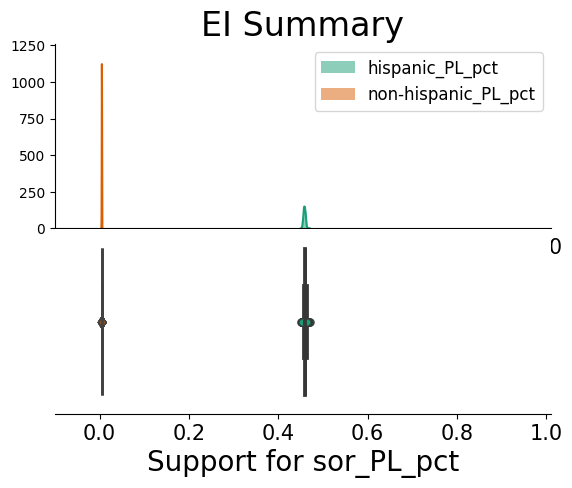

In [7]:


# (H, SOR_0)
ma_sor_hispanic = two_by_two(state_dfs[1], 'sor_PL_pct', 'hispanic_PL_pct', 'totpop_PL')
plot_ei(ma_sor_hispanic)
er(np.array(state_dfs[1]['hispanic_PL_pct']), np.array(state_dfs[1]['sor_PL_pct']), np.array(state_dfs[1]['totpop_PL']).astype(int))

# # (Brazilian, SOR_0)
# ma_sor_brazil = two_by_two(state_dfs[1], 'sor_ACS_pct', 'brazilian_ACS_pct', 'totpop_ACS')
# plot(ma_sor_brazil)
# er(np.array(state_dfs[1]['brazilian_ACS_pct']), np.array(state_dfs[1]['sor_ACS_pct']), np.array(state_dfs[1]['totpop_ACS']).astype(int))

# # (Guyanese, SOR_0)
# pop = 'guyanese_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ma_sor_guy = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_sor_guy)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Cabo Verdean, SOR_0)
# pop = 'cabo_verdean_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ma_sor_cabo = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_sor_cabo)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Belizean, SOR_0)
# pop = 'belizean_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ma_sor_bel = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_sor_bel)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Brazilian, H)
# pop = 'brazilian_ACS_pct'
# race = 'hispanic_PL_pct'
# total_pop = 'totpop_PL'
# ma_hispanic_brazil = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_hispanic_brazil)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Guyanese, H)
# pop = 'guyanese_ACS_pct'
# race = 'hispanic_PL_pct'
# total_pop = 'totpop_PL'
# ma_hispanic_guy = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_hispanic_guy)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Cabo Verde, B_0)
# pop = 'cabo_verdean_ACS_pct'
# race = 'black_PL_pct'
# total_pop = 'totpop_PL'
# ma_black_cabo = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_black_cabo)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Belizean, H)
# pop = 'belizean_ACS_pct'
# race = 'hispanic_PL_pct'
# total_pop = 'totpop_PL'
# ma_hispanic_belize = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_hispanic_belize)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Mena_WB, SOR_0)
# pop = 'mena_world_bank_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ma_sor_world_bank = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_sor_world_bank)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Mena_UNHC, SOR_0)
# pop = 'mena_unhcr_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ma_sor_unhcr = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_sor_unhcr)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Mena_UNSC, SOR_0)
# pop = 'mena_unsd_ACS_pct'
# race = 'sor_ACS_pct'
# total_pop = 'totpop_ACS'
# ma_sor_unsd = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_sor_unsd)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Mena_WB, W_0)
# pop = 'mena_world_bank_ACS_pct'
# race = 'white_PL_pct'
# total_pop = 'totpop_PL'
# ma_w_world_bank = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_w_world_bank)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Mena_UNHC, W_0)
# pop = 'mena_unhcr_ACS_pct'
# race = 'white_PL_pct'
# total_pop = 'totpop_PL'
# ma_w_unhcr = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_w_unhcr)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

# # (Mena_UNSC, W_0)
# pop = 'mena_unsd_ACS_pct'
# race = 'white_PL_pct'
# total_pop = 'totpop_PL'
# ma_w_unsd = two_by_two(state_dfs[1], race, pop, total_pop)
# plot(ma_w_unsd)
# er(np.array(state_dfs[1][pop]), np.array(state_dfs[1][race]), np.array(state_dfs[1][total_pop]).astype(int))

Goodmans ER, weighted by population
        Est. fraction of hispanic_PL_pct
        voters who voted for sor_PL_pct is
        0.601
        Est. fraction of non- hispanic_PL_pct
        voters who voted for sor_PL_pct is
        -0.041
        


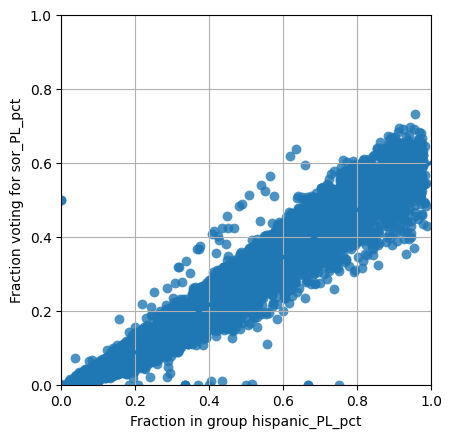

: 

In [ ]:
er(
    group_fraction_2by2=np.array(state_dfs[0]['hispanic_PL_pct']), 
    votes_fraction_2by2=np.array(state_dfs[0]['sor_PL_pct']), 
    precinct_pops=np.array(state_dfs[0]['totpop_PL']).astype(int),
    demographic_group_name_2by2='hispanic_PL_pct',
    candidate_name_2by2='sor_PL_pct',
)


        # group_fraction_2by2,
        # votes_fraction_2by2,
        # precinct_pops, # Must include populations if weighting by population
        # demographic_group_name=demographic_group_name_2by2,
        # candidate_name=candidate_name_2by2

In [ ]:
sdfsadf

## Tracts, Michigan

In [ ]:


# (H, SOR_0)
pop = 'hispanic_PL_pct'
race = 'sor_PL_pct'
total_pop = 'totpop_PL'
mi_sor_hispanic = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_hispanic)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Brazilian, SOR_0)
pop = 'brazilian_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
mi_sor_brazil = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_brazil)
er(np.array(state_dfs[2]['brazilian_ACS_pct']), np.array(state_dfs[2]['sor_ACS_pct']), np.array(state_dfs[2]['totpop_ACS']).astype(int))

# (Guyanese, SOR_0)
pop = 'guyanese_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
mi_sor_guy = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_guy)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Cabo Verdean, SOR_0)
pop = 'cabo_verdean_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
mi_sor_cabo = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_cabo)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Belizean, SOR_0)
pop = 'belizean_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
mi_sor_bel = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_bel)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Brazilian, H)
pop = 'brazilian_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
mi_hispanic_brazil = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_hispanic_brazil)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Guyanese, H)
pop = 'guyanese_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
mi_hispanic_guy = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_hispanic_guy)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Cabo Verde, B_0)
pop = 'cabo_verdean_ACS_pct'
race = 'black_PL_pct'
total_pop = 'totpop_PL'
mi_black_cabo = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_black_cabo)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Belizean, H)
pop = 'belizean_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
mi_hispanic_belize = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_hispanic_belize)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Mena_WB, SOR_0)
pop = 'mena_world_bank_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
mi_sor_world_bank = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_world_bank)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Mena_UNHC, SOR_0)
pop = 'mena_unhcr_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
mi_sor_unhcr = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_unhcr)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Mena_UNSC, SOR_0)
pop = 'mena_unsd_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
mi_sor_unsd = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_sor_unsd)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Mena_WB, W_0)
pop = 'mena_world_bank_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
mi_w_world_bank = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_w_world_bank)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Mena_UNHC, W_0)
pop = 'mena_unhcr_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
mi_w_unhcr = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_w_unhcr)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

# (Mena_UNSC, W_0)
pop = 'mena_unsd_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
mi_w_unsd = two_by_two(state_dfs[2], race, pop, total_pop)
plot(mi_w_unsd)
er(np.array(state_dfs[2][pop]), np.array(state_dfs[2][race]), np.array(state_dfs[2][total_pop]).astype(int))

## Tracts, New York

In [ ]:


# (H, SOR_0)
ny_sor_hispanic = two_by_two(state_dfs[3], 'sor_PL_pct', 'hispanic_PL_pct', 'totpop_PL')
plot(ny_sor_hispanic)
er(np.array(state_dfs[3]['hispanic_PL_pct']), np.array(state_dfs[3]['sor_PL_pct']), np.array(state_dfs[3]['totpop_PL']).astype(int))

# (Brazilian, SOR_0)
ny_sor_brazil = two_by_two(state_dfs[3], 'sor_ACS_pct', 'brazilian_ACS_pct', 'totpop_ACS')
plot(ny_sor_brazil)
er(np.array(state_dfs[3]['brazilian_ACS_pct']), np.array(state_dfs[3]['sor_ACS_pct']), np.array(state_dfs[3]['totpop_ACS']).astype(int))

# (Guyanese, SOR_0)
pop = 'guyanese_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
ny_sor_guy = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_sor_guy)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Cabo Verdean, SOR_0)
pop = 'cabo_verdean_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
ny_sor_cabo = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_sor_cabo)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Belizean, SOR_0)
pop = 'belizean_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
ny_sor_bel = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_sor_bel)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Brazilian, H)
pop = 'brazilian_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
ny_hispanic_brazil = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_hispanic_brazil)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Guyanese, H)
pop = 'guyanese_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
ny_hispanic_guy = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_hispanic_guy)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Cabo Verde, B_0)
pop = 'cabo_verdean_ACS_pct'
race = 'black_PL_pct'
total_pop = 'totpop_PL'
ny_black_cabo = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_black_cabo)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Belizean, H)
pop = 'belizean_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
ny_hispanic_belize = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_hispanic_belize)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Mena_WB, SOR_0)
pop = 'mena_world_bank_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
ny_sor_world_bank = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_sor_world_bank)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Mena_UNHC, SOR_0)
pop = 'mena_unhcr_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
ny_sor_unhcr = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_sor_unhcr)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Mena_UNSC, SOR_0)
pop = 'mena_unsd_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
ny_sor_unsd = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_sor_unsd)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Mena_WB, W_0)
pop = 'mena_world_bank_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
ny_w_world_bank = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_w_world_bank)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Mena_UNHC, W_0)
pop = 'mena_unhcr_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
ny_w_unhcr = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_w_unhcr)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

# (Mena_UNSC, W_0)
pop = 'mena_unsd_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
ny_w_unsd = two_by_two(state_dfs[3], race, pop, total_pop)
plot(ny_w_unsd)
er(np.array(state_dfs[3][pop]), np.array(state_dfs[3][race]), np.array(state_dfs[3][total_pop]).astype(int))

## Tracts, Texas

In [ ]:


# (H, SOR_0)
tx_sor_hispanic = two_by_two(state_dfs[4], 'sor_PL_pct', 'hispanic_PL_pct', 'totpop_PL')
plot(tx_sor_hispanic)
er(np.array(state_dfs[4]['hispanic_PL_pct']), np.array(state_dfs[4]['sor_PL_pct']), np.array(state_dfs[4]['totpop_PL']).astype(int))

# (Brazilian, SOR_0)
tx_sor_brazil = two_by_two(state_dfs[4], 'sor_ACS_pct', 'brazilian_ACS_pct', 'totpop_ACS')
plot(tx_sor_brazil)
er(np.array(state_dfs[4]['brazilian_ACS_pct']), np.array(state_dfs[4]['sor_ACS_pct']), np.array(state_dfs[4]['totpop_ACS']).astype(int))

# (Guyanese, SOR_0)
pop = 'guyanese_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
tx_sor_guy = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_sor_guy)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Cabo Verdean, SOR_0)
pop = 'cabo_verdean_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
tx_sor_cabo = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_sor_cabo)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Belizean, SOR_0)
pop = 'belizean_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
tx_sor_bel = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_sor_bel)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Brazilian, H)
pop = 'brazilian_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
tx_hispanic_brazil = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_hispanic_brazil)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Guyanese, H)
pop = 'guyanese_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
tx_hispanic_guy = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_hispanic_guy)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Cabo Verde, B_0)
pop = 'cabo_verdean_ACS_pct'
race = 'black_PL_pct'
total_pop = 'totpop_PL'
tx_black_cabo = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_black_cabo)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Belizean, H)
pop = 'belizean_ACS_pct'
race = 'hispanic_PL_pct'
total_pop = 'totpop_PL'
tx_hispanic_belize = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_hispanic_belize)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Mena_WB, SOR_0)
pop = 'mena_world_bank_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
tx_sor_world_bank = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_sor_world_bank)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Mena_UNHC, SOR_0)
pop = 'mena_unhcr_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
tx_sor_unhcr = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_sor_unhcr)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Mena_UNSC, SOR_0)
pop = 'mena_unsd_ACS_pct'
race = 'sor_ACS_pct'
total_pop = 'totpop_ACS'
tx_sor_unsd = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_sor_unsd)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Mena_WB, W_0)
pop = 'mena_world_bank_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
tx_w_world_bank = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_w_world_bank)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Mena_UNHC, W_0)
pop = 'mena_unhcr_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
tx_w_unhcr = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_w_unhcr)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

# (Mena_UNSC, W_0)
pop = 'mena_unsd_ACS_pct'
race = 'white_PL_pct'
total_pop = 'totpop_PL'
tx_w_unsd = two_by_two(state_dfs[4], race, pop, total_pop)
plot(tx_w_unsd)
er(np.array(state_dfs[4][pop]), np.array(state_dfs[4][race]), np.array(state_dfs[4][total_pop]).astype(int))

## Chloe's Work

In [ ]:
sum(state_dfs[0]["hispanic_PL_pct"].isna())

32

In [ ]:
state_dfs[0].fillna(0, inplace = True)

In [ ]:
candidate_name_2by2 = "SORO"
demographic_group_name_2by2 = "Hispanic"
precinct_names = state_dfs[0]['tract'].astype(str)
group_fraction_2by2 = np.array(state_dfs[0]["hispanic_PL_pct"]) # Change this AND candidate name below
votes_fraction_2by2 = np.array(state_dfs[0]["sor_PL_pct"]) #Change this AND group name below
precinct_pops = np.array(state_dfs[0]["totpop_PL"]).astype(int)
ei_2by2 = TwoByTwoEI(model_name="king99_pareto_modification", pareto_scale=15, pareto_shape=2)
ei_2by2.fit(group_fraction_2by2,
      votes_fraction_2by2,
      precinct_pops,
      demographic_group_name=demographic_group_name_2by2,
      candidate_name=candidate_name_2by2,
      precinct_names=precinct_names, # omit this line if you don't have or don't want to use precinct names
      chains=4
)
# Generate a simple report to summarize the results
print(ei_2by2.summary())

/Users/ireland/anaconda3/lib/python3.11/site-packages/pyei/two_by_two.py:812: UserWarning: Precinct names are not unique. This may interfere with passing precinct names to precinct_level_plot().
  warnings.warn(


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print(ei_2by2.summary())

TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
state

array([0.02633311, 0.02048976, 0.03470203, ..., 0.03735705, 0.02698463,
       0.00796813])

In [ ]:
candidate_name_2by2 = "SOR0"
demographic_group_name_2by2 = "Hispanic"
precinct_names = e_df['counties']
group_fraction_2by2 = np.array(e_df["h_pct"]) # Change this AND candidate name below
votes_fraction_2by2 = np.array(e_df["sor_pct"]) #Change this AND group name below
precinct_pops = np.array(e_df["total"]).astype(int)
ei_2by2 = TwoByTwoEI(model_name="king99_pareto_modification", pareto_scale=15, pareto_shape=2)
ei_2by2.fit(group_fraction_2by2,
      votes_fraction_2by2,
      precinct_pops,
      demographic_group_name=demographic_group_name_2by2,
      candidate_name=candidate_name_2by2,
      precinct_names=precinct_names, # omit this line if you don't have or don't want to use precinct names
      chains=4
)
# Generate a simple report to summarize the results
print(ei_2by2.summary())

goodmans_er = GoodmansER(is_weighted_regression="True")

goodmans_er.fit(group_fraction_2by2,
    votes_fraction_2by2,
    precinct_pops, # Must include populations if weighting by population
    demographic_group_name=demographic_group_name_2by2,
    candidate_name=candidate_name_2by2
)

print(goodmans_er.summary())
goodmans_er.plot()